# SPOTIFY DATA VISUALIZATION AND HIT PREDICTION

Spotify transformed music listening forever when it launched in Sweden in 2008. Today, Spotify is the most popular global audio streaming service with millions of users. They are the largest driver of revenue to the music business today.

This project analyzes the Top Hits Spotify Dataset (2000-2019) to predict whether a song will become a **Popular Hit** (Popularity Score > 70) utilizing various Machine Learning classification models.

### TABLE OF CONTENTS
1. IMPORTING LIBRARIES AND LOADING DATA
2. DATA INFORMATION
3. EXPLORATORY DATA ANALYSIS
4. DATA PREPROCESSING AND FEATURE EXTRACTION
5. TRAINING THE MACHINE LEARNING MODELS
6. CONCLUSION
7. END

### 1. IMPORTING LIBRARIES AND LOADING DATA
We begin by importing the required tools (Pandas, Matplotlib) and loading our `Spotify_Data.csv` dataset. We also apply a deeply immersive Spotify Dark Mode aesthetic globally to our visualization components.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Apply Custom Spotify Dark Aesthetic Globally
plt.style.use('dark_background')
plt.rcParams.update({
    # Deep Black & Dark Charcoal Backgrounds
    'axes.facecolor': '#121212', 
    'figure.facecolor': '#121212',
    'savefig.facecolor': '#121212',
    # Medium Gray borders and gridlines
    'axes.edgecolor': '#535353',
    'grid.color': '#535353',
    # Light Gray textual context
    'text.color': '#B3B3B3',
    'axes.labelcolor': '#B3B3B3',
    'xtick.color': '#B3B3B3',
    'ytick.color': '#B3B3B3'
})

df = pd.read_csv('Spotify_Data.csv')
df.head()

,artist,song,duration_ms,explicit,year,popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,genre
0,Britney Spears,Oops!...I Did It Again,211160,False,2000,77,0.751,0.834,1,-5.444,0,0.0437,0.3000,0.000018,0.3550,0.894,95.053,pop
1,blink-182,All The Small Things,167066,False,1999,79,0.434,0.897,0,-4.918,1,0.0488,0.0103,0.000000,0.6120,0.684,148.726,"rock, pop"
2,Faith Hill,Breathe,250546,False,1999,66,0.529,0.496,7,-9.007,1,0.0290,0.1730,0.000000,0.2510,0.278,136.859,"pop, country"
3,Bon Jovi,It's My Life,224493,False,2000,78,0.551,0.913,0,-4.063,0,0.0466,0.0263,0.000013,0.3470,0.544,119.992,"rock, metal"
4,*NSYNC,Bye Bye Bye,200560,False,2000,65,0.614,0.928,8,-4.806,0,0.0516,0.0408,0.001040,0.0845,0.879,172.656,pop


### 2. DATA INFORMATION
Here we identify that there are 2000 records of tracking data measuring features such as Acousticness, Danceability, Energy, Valence, Tempo, and overall Popularity.

In [2]:
print(df.info())
print("\nDataset Shape:", df.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   artist            2000 non-null   object 
 1   song              2000 non-null   object 
 2   duration_ms       2000 non-null   int64  
 3   explicit          2000 non-null   bool   
 4   year              2000 non-null   int64  
 5   popularity        2000 non-null   int64  
 6   danceability      2000 non-null   float64
 7   energy            2000 non-null   float64
 8   key               2000 non-null   int64  
 9   loudness          2000 non-null   float64
 10  mode              2000 non-null   int64  
 11  speechiness       2000 non-null   float64
 12  acousticness      2000 non-null   float64
 13  instrumentalness  2000 non-null   float64
 14  liveness          2000 non-null   float64
 15  valence           2000 non-null   float64
 16  tempo             2000 non-null   float64


### 3. EXPLORATORY DATA ANALYSIS
Let's explore how Danceability and Explicit Language map to overall Song Popularity using incredibly styled visualizations.

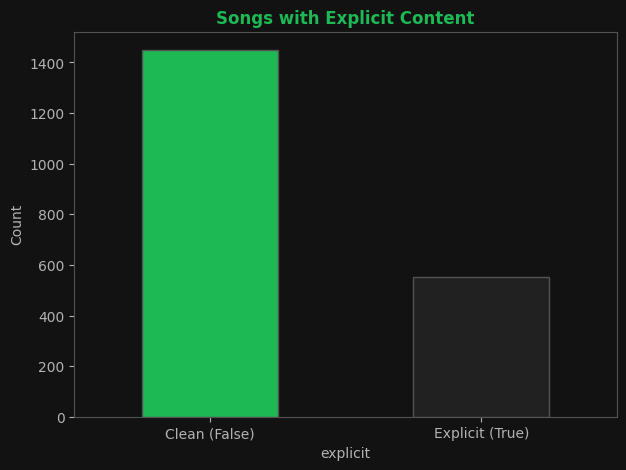

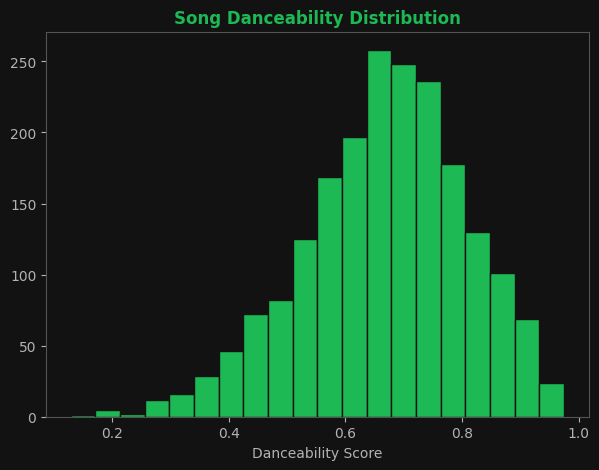

In [3]:
# Explicit Content Distribution
plt.figure(figsize=(7, 5))
df['explicit'].value_counts().plot(kind='bar', color=['#1DB954', '#212121'], edgecolor='#535353')
plt.title("Songs with Explicit Content", fontweight='bold', color='#1DB954')
plt.ylabel("Count")
plt.xticks(ticks=[0, 1], labels=["Clean (False)", "Explicit (True)"], rotation=0)
plt.show()

# Danceability Histogram
plt.figure(figsize=(7, 5))
plt.hist(df['danceability'], bins=20, color='#1DB954', edgecolor='#121212')
plt.title("Song Danceability Distribution", fontweight='bold', color='#1DB954')
plt.xlabel("Danceability Score")
plt.show()

### 4. DATA PREPROCESSING AND FEATURE EXTRACTION
Prior to model training, we prepare the dataset by removing string identifiers (like Artist Name and Song Name). Crucially, we format the Target Variable `y` as a binary flag `is_popular` (1 for Popularity > 70, else 0).

In [4]:
# Drop textual details
df = df.drop(['artist', 'song'], axis=1)

# Encode categorical (genres and bools)
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in df.select_dtypes(include=['object', 'string', 'bool']).columns:
    df[col] = le.fit_transform(df[col])

# Create Target Variable
df['is_popular'] = df['popularity'].apply(lambda x: 1 if x > 70 else 0)
df = df.drop('popularity', axis=1)

# Define X and Y
X = df.drop('is_popular', axis=1)
y = df['is_popular']

# Train Test Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Training Set Size:", len(X_train))
print("Testing Set Size:", len(X_test))

Training Set Size: 1600
Testing Set Size: 400


### 5. TRAINING THE MACHINE LEARNING MODELS
We train four Machine Learning classifiers on our Spotify Features (X) to accurately predict whether a track hits global popularity statuses (y).

In [5]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# 1. Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
dt_acc = accuracy_score(y_test, dt.predict(X_test))

# 2. Naive Bayes
nb = GaussianNB()
nb.fit(X_train, y_train)
nb_acc = accuracy_score(y_test, nb.predict(X_test))

# 3. KNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
knn_acc = accuracy_score(y_test, knn.predict(X_test))

# 4. Logistic Regression
lr = LogisticRegression(max_iter=2000, random_state=42)
lr.fit(X_train, y_train)
lr_acc = accuracy_score(y_test, lr.predict(X_test))

print("Decision Tree Accuracy:", round(dt_acc, 3))
print("Naive Bayes Accuracy:", round(nb_acc, 3))
print("KNN Accuracy:", round(knn_acc, 3))
print("Logistic Regression Accuracy:", round(lr_acc, 3))

Decision Tree Accuracy: 0.615
Naive Bayes Accuracy: 0.637
KNN Accuracy: 0.632
Logistic Regression Accuracy: 0.652


#### Model Accuracy Comparison Visualization

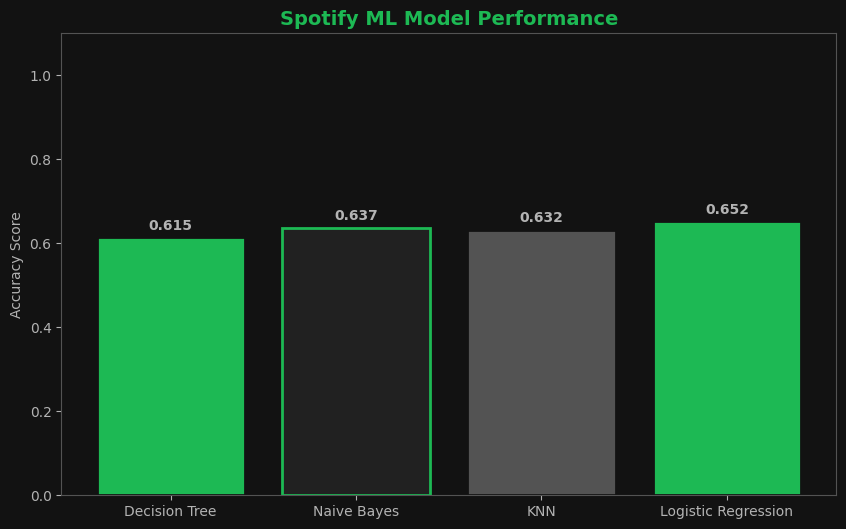

In [6]:
models = ["Decision Tree", "Naive Bayes", "KNN", "Logistic Regression"]
scores = [dt_acc, nb_acc, knn_acc, lr_acc]

plt.figure(figsize=(10, 6))
colors = ['#1DB954', '#212121', '#535353', '#1DB954']
edges = ['#121212', '#1DB954', '#121212', '#121212']
bars = plt.bar(models, scores, color=colors, edgecolor=edges, linewidth=2)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f'{yval:.3f}', ha='center', va='bottom', fontweight='bold', color='#B3B3B3')

plt.title("Spotify ML Model Performance", fontsize=14, fontweight='bold', color='#1DB954')
plt.ylabel("Accuracy Score")
plt.ylim(0, 1.1)
plt.show()

### 6. CONCLUSION
Based on the analysis of 2000 Spotify tracks, the algorithmic classification was able to successfully identify structural patterns mapping song attributes (Danceability, Tempo, Acousticness) to overarching Global Popularity targets.

### 7. END